In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy

import treecorr

import pyccl as ccl

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 16,          # base font size
    "axes.labelsize": 18,     # x and y labels
    "axes.titlesize": 18,     # title
    "legend.fontsize": 14,    # legend
    "xtick.labelsize": 14,    # x tick labels
    "ytick.labelsize": 14,    # y tick labels
})


import sys
import os
import copy

sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code")) 

In [2]:
from halo_model.power_spectra.matter_power_baryons import MatterPowerBaryons
from halo_model.power_spectra.matter_power import MatterPower
from halo_model.power_spectra.Pm_computer import Pm_computer
from halo_model.halos.base.profile.profile import CompositeProfile

from halo_model.config.config import Config

In [3]:
from halo_model.halos.base.clump_mass_func.models.giocoli2010_mod import ClumpMassGiocoli2010_mod
from halo_model.halos.base.clump_mass_func.models.giocoli2010 import ClumpMassGiocoli2010
from halo_model.halos.base.clump_mass_func.clump_mass_func import ClumpMassFunc

from halo_model.halos.base.concentration.models.neto2007 import ConcentrationNeto2007
from halo_model.halos.base.concentration.models.scaled import ConcentrationScaled

from halo_model.halos.base.mass_func.models.tinker2008 import MassFuncTinker2008

from halo_model.halos.base.profile.models.nfw import ProfileNFW
from halo_model.halos.base.profile.models.stellar_truncated_powerlaw import ProfileStellarTruncatedPowerLaw
from halo_model.halos.base.profile.models.pointmass import ProfilePointMass
from halo_model.halos.base.profile.models.gas_cored_powerlaw import ProfileGasCoredPowerLaw


from halo_model.halos.base.bias.models.tinker2010 import BiasTinker2010
from halo_model.halos.base.r_vir.models.SO import R_virSO

from halo_model.halos.base.shmr.models.moster2013 import SHMRMoster2013
from halo_model.halos.base.shmr.models.moster2013_centrals import SHMRMoster2013Centrals
from halo_model.halos.base.shmr.models.Niemiec2022 import SMHRNiemiec2022

In [4]:
#set config & create ccl cosmology object
cfg = Config()

cfg.z_max = 2
cfg.z_min = 0
cfg.N_z = 6
cfg.N_m = 16
cfg.N_M = 32

# Cosmology parameters 

flat = True
H0 = cfg.cosmo.H0
Om0 = cfg.cosmo.Om0
Ob0 = cfg.cosmo.Ob0
sigma8 = cfg.cosmo.sigma8
ns = cfg.cosmo.ns

cosmo = ccl.Cosmology(Omega_c = Om0, Omega_b=Ob0, h=0.01*H0, sigma8=sigma8, n_s=ns)

In [5]:
c_smooth = ConcentrationNeto2007(cfg)
c_clump = ConcentrationScaled(cfg, c_smooth)

mass_func = MassFuncTinker2008(cfg)

shmr = SHMRMoster2013(cfg, c_smooth)
shmr_central = SHMRMoster2013Centrals(cfg, c_smooth)

smooth_profile_dm = ProfileNFW(c_smooth, R_virSO(cfg))
clump_profile_dm = ProfileNFW(c_clump, R_virSO(cfg))

bias = BiasTinker2010(cfg)

clump_distribution = ProfileNFW(c_smooth, R_virSO(cfg))

computing power spectrum at redshift 2.0
0.0
interpolating Ic and Jc functions...
Computing Fourier transform of gas profile...
Computing Fourier transform of stellar profile...
interpolating Ic and Jc functions...
computing power spectrum at redshift 1.6
0.0
interpolating Ic and Jc functions...
Computing Fourier transform of gas profile...
Computing Fourier transform of stellar profile...
interpolating Ic and Jc functions...
computing power spectrum at redshift 1.2
0.0
interpolating Ic and Jc functions...
Computing Fourier transform of gas profile...
Computing Fourier transform of stellar profile...
interpolating Ic and Jc functions...
computing power spectrum at redshift 0.8
0.0
interpolating Ic and Jc functions...
Computing Fourier transform of gas profile...
Computing Fourier transform of stellar profile...
interpolating Ic and Jc functions...
computing power spectrum at redshift 0.4
0.0
interpolating Ic and Jc functions...
Computing Fourier transform of gas profile...
Computing Fo

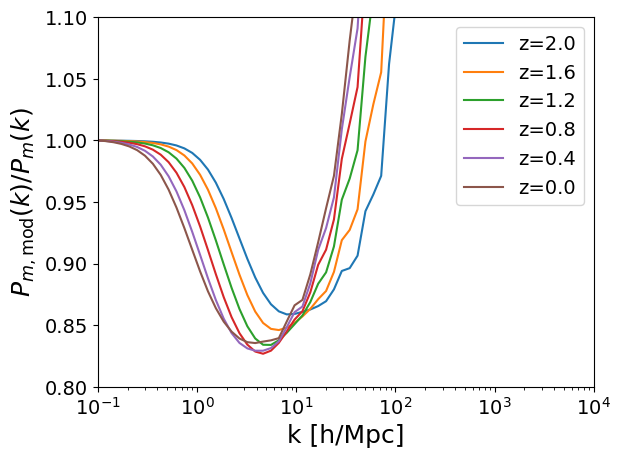

In [6]:
#computing model power spectra
z_grid = np.linspace(cfg.z_max, cfg.z_min, cfg.N_z) # from high redshift to low redshift so scale factor is monotonically increasing
k_grid = np.logspace(np.log10(cfg.k_min), np.log10(cfg.k_max), cfg.N_k)

Nz = len(z_grid)
Nk = len(k_grid)

Pm_dmo_grid = np.zeros((Nz, Nk))   # shape (z, k)
Pm_baryon_grid = np.zeros((Nz, Nk)) 

for i,z in enumerate(z_grid):
    cfg_local = copy.deepcopy(cfg)
    cfg_local.z = z

    print(f"computing power spectrum at redshift {z:.1f}")
    
    # compute CDM power spectrum
    clump_mass_func = ClumpMassGiocoli2010(cfg_local)
    
    print(clump_mass_func.f(1e4))
    
    Pm_dmo = MatterPower(cfg_local, 
                    mass_func=mass_func, 
                    smooth_profile=smooth_profile_dm,
                    bias=bias,
                    clump_mass_func=clump_mass_func, 
                    clump_profile=clump_profile_dm, 
                    clump_distribution=clump_distribution)
        
    Pm_dmo_dict = Pm_computer(Pm_dmo, k_grid)
    Pm_dmo_tot = Pm_dmo_dict['P_tot']
    Pm_dmo_grid[i, :] = Pm_dmo_tot 
    

    # compute baryon power spectrum
    
    gas_profile = ProfileGasCoredPowerLaw(cfg_local, shmr, c_smooth)
    stellar_profile = ProfileStellarTruncatedPowerLaw(cfg_local, c_smooth)

    Pm_baryon = MatterPowerBaryons(cfg_local, 
                    mass_func=mass_func, 
                    shmr=shmr,
                    shmr_central=shmr_central,
                    smooth_profile_dm=smooth_profile_dm,
                    stellar_profile=stellar_profile, 
                    gas_profile=gas_profile,
                    bias=bias,
                    clump_mass_func=clump_mass_func, 
                    clump_profile_dm=clump_profile_dm, 
                    clump_distribution=clump_distribution)
    
    Pm_baryon_dict = Pm_computer(Pm_baryon, k_grid)
    Pm_baryon_tot = Pm_baryon_dict['P_tot']
    Pm_baryon_grid[i, :] = Pm_baryon_tot
    
    
    plt.plot(k_grid, Pm_baryon_tot/Pm_dmo_tot, label=f'z={z:.1f}')
    
plt.xscale("log")
plt.ylim(0.8, 1.1)
plt.xlim(np.min(k_grid), np.max(k_grid))
plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P_{m, \mathrm{mod}}(k) / P_m(k)$')
plt.legend()
plt.show()

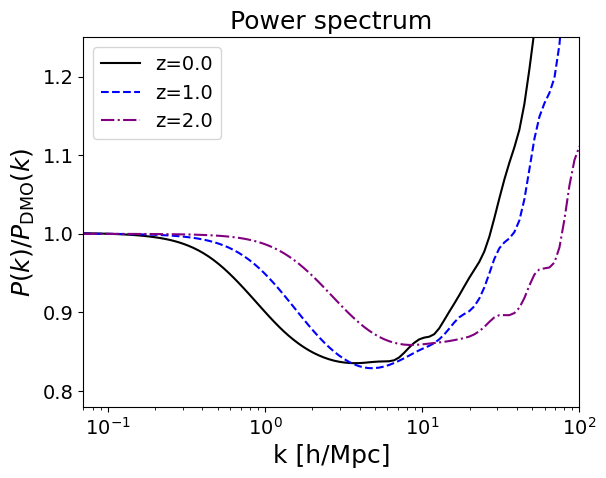

In [7]:
# create ccl Pk2D objects for CDM and WDM power spectra
sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code/plotting_code/baryonification")) 

a_grid = 1/(1+z_grid)

Pk_dmo = ccl.Pk2D(
    a_arr=a_grid,
    lk_arr=np.log(k_grid),
    pk_arr=Pm_dmo_grid,
    is_logp=False  
)
Pk_baryon = ccl.Pk2D(
    a_arr=a_grid,
    lk_arr=np.log(k_grid),
    pk_arr=Pm_baryon_grid,
    is_logp=False  
)

z_grid_plot = np.linspace(0, 2, 3)
k_grid_plot = np.geomspace(7e-2, 1e2, 100)
for z, color, linestyle in zip(z_grid_plot, 
                               ['black', 'blue', 'purple'],
                               ['-', "--", "-."]):
    plt.plot(k_grid_plot, 
             Pk_baryon(k_grid_plot, 1/(1 + z)) / Pk_dmo(k_grid_plot, 1/(1 + z)), 
             label=f'z={z:.1f}',
             color=color,
             linestyle=linestyle,
             )
    
plt.legend(loc="upper left")
plt.ylim(0.78, 1.25)
plt.xlim(7e-2, 1e2)
plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P(k) / P_\mathrm{DMO}(k)$')

plt.title("Power spectrum")
plt.xscale("log")

plt.savefig("baryonification_power_spectrum_various_redshifts.pdf",
            bbox_inches="tight")
plt.show()

fraction of blue galaxies:  0.7813117875635198


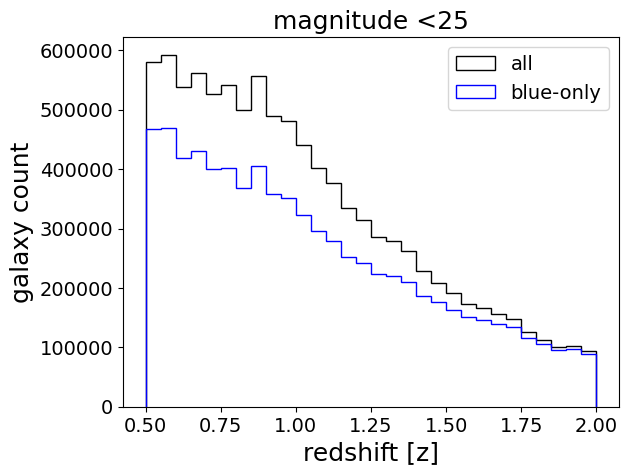

In [8]:
# Load in source distribution from flagship

from astropy.io import fits
import numpy as np

# fits_file = fits.util.get_testdata_filepath("23586.fits")
hdul = fits.open("/home/milan/Desktop/thesis/flagship_sim/25224.fits")
hdr = hdul[1].header
data = hdul[1].data

z = data['true_redshift_gal']
flux = data['euclid_vis']
mag = -2.5 * np.log10(flux) - 48.6


# create a mask in redshift:
z_min = 0.5
z_max = 2
mask = np.where((z > z_min) & (z < z_max) & (mag < 25))

z = z[mask]
ra = data['ra_gal'][mask]
dec = data['dec_gal'][mask]

kappa = data['kappa'][mask]
gamma1 = data['gamma1'][mask]
gamma2 = data['gamma2'][mask]
eps1 = data['eps1_gal'][mask]
eps2 = data['eps2_gal'][mask]

u_flux_abs = data['cfht_u_abs'][mask]
r_flux_abs = data['subaru_r_abs'][mask]

z_edges = np.linspace(0.5, 2, 31)
plt.hist(z, bins=z_edges, histtype='step', label='all', color='black')

# now lets make cuts so we only select blue galaxies, for this we follow along 
# Euclid preparation:
# Calibrated intrinsic galaxy alignments in the Euclid Flagship simulation
# Euclid Collaboration: K. Hoffmann ....
# page 4 bottom right

h = 0.67
u_mag_abs = -2.5 * np.log10(u_flux_abs) - 48.6 + 5 * np.log10(h)
r_mag_abs = -2.5 * np.log10(r_flux_abs) - 48.6 + 5 * np.log10(h)

mask = (u_mag_abs - r_mag_abs < 1.32)

fraction_blue_galaxies = np.sum(mask) / len(mask)
print("fraction of blue galaxies: ", fraction_blue_galaxies)

z = z[mask]
ra = ra[mask]
dec = dec[mask]

kappa = kappa[mask]
gamma1 = gamma1[mask]
gamma2 = gamma2[mask]
eps1 = eps1[mask]
eps2 = eps2[mask]

z_edges = np.linspace(0.5, 2, 31)
plt.hist(z, bins=z_edges, histtype='step', label='blue-only', color='blue')
plt.xlabel('redshift [z]')
plt.ylabel('galaxy count')
plt.title('magnitude <25')
plt.legend()
plt.show()


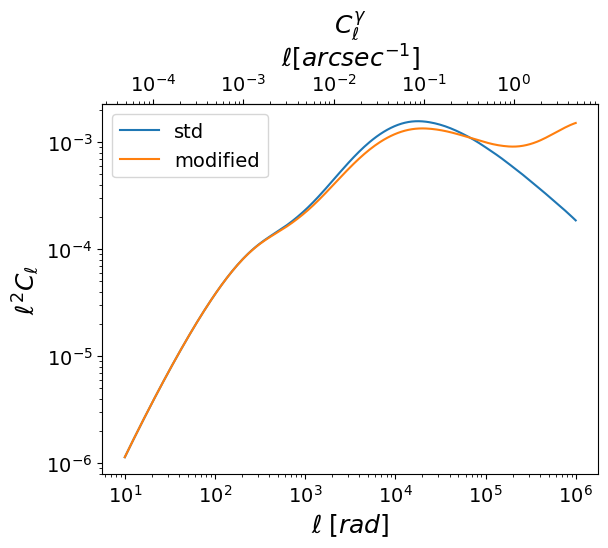

In [9]:
# compute the Cls 

# source distribution follows the sources from the flagship simulation
z_edges = np.linspace(z_min, cfg.z_max, 10)
nzs = np.ndarray((z_edges.shape))

for i in range(len(z_edges) - 1):
    nzs[i] = np.sum(np.where((z<z_edges[i+1]) & (z>z_edges[i])))
    nzs /= len(z)

# define shear tracers
tr = ccl.WeakLensingTracer(cosmo=cosmo, dndz=(z_edges, nzs))

# compute C_ell
ell = np.logspace(1, 6, 256 + 1)
cl = ccl.angular_cl(cosmo, tracer1=tr, tracer2=tr, ell=ell, p_of_k_a=Pk_dmo)
cl_mod = ccl.angular_cl(cosmo, tracer1=tr, tracer2=tr, ell=ell, p_of_k_a=Pk_baryon)


#plot the Cls

plt.plot(ell, ell**2*cl, label='std')
plt.plot(ell, ell**2*cl_mod, label='modified')

plt.title(r"$C_\ell^\gamma$")

plt.xlabel(r'$\ell \;[rad]$')
plt.ylabel(r'$\ell^2 C_\ell$')

def rad_to_arcsec_inv(x):
    return x / (180/np.pi * 3600)

def arcsec_to_rad_inv(x):
    return x / (np.pi/180 / 3600)

secax = plt.gca().secondary_xaxis('top', functions=(rad_to_arcsec_inv, arcsec_to_rad_inv))
secax.set_xlabel(r'$\ell [arcsec^{-1}]$')
plt.legend()
plt.xscale('log')
plt.yscale("log")
plt.show()

In [10]:
#compute xi_p, xi_m & set theta range
tmin = 1
tmax = 1e3

nthet = 10
theta_deg = np.geomspace(tmin/3600, tmax/3600, nthet)

xi_plus = ccl.correlation(cosmo, ell=ell, C_ell=cl, theta=theta_deg, type='GG+', method='bessel')
xi_plus_mod = ccl.correlation(cosmo, ell=ell, C_ell=cl_mod, theta=theta_deg, type='GG+', method='bessel')

#setup config for treecorr

#create theta bins
nbins = nthet

min_sep = 1/3600
max_sep = 1e3/3600

log_min = np.log10(min_sep)
log_max = np.log10(max_sep)
dlog = (log_max - log_min) / nbins

theta = theta_deg

config = {
    "nbins": nbins,
    "min_sep":  min_sep,
    "max_sep": max_sep,
    "sep_units": "degrees",
    "bin_type": "Log",

    # "min_rpar": PI_max,
    # "max_rpar": PI_max,

    "bin_slop": None, # None sets bin_slop = 0.1
    #"angle_slop": None,

    # "split_method": "mean", # How to split the cells in the tree when building the tree structure. 
    "metric": "Euclidean", #see metrics: https://rmjarvis.github.io/TreeCorr/_build/html/metric.html#metrics 
    "var_method": 'jackknife',
    "cross_patch_weight": 'simple',
}

In [11]:
# get pairs function

def get_pairs(config, redshift_separation=0):
    mask1 = (z < 0.9 - redshift_separation/2)
    mask2 = (z > 0.9 + redshift_separation/2)
    print(np.sum(mask1)/len(mask1), np.sum(mask1), np.sum(mask2))

    cat1 = treecorr.Catalog(
        ra=ra[mask1], dec=dec[mask1], ra_units='deg', dec_units='deg', 
    )

    cat2 = treecorr.Catalog(
        ra=ra[mask2], dec=dec[mask2], ra_units='deg', dec_units='deg', 
    )

    nn = treecorr.NNCorrelation(config)
    nn.process(cat1, cat2)
    pairs_per_bin = nn.npairs

    return pairs_per_bin

pairs_per_bin = get_pairs(config, redshift_separation=0.05)


0.4090298370694683 3153609 4171184


In [12]:
# get covariance function

def get_cov_delz(config, npatch, method='jackknife', including_shear=False, redshift_separation = 0):
    mask1 = (z < 0.9 - redshift_separation/2)
    mask2 = (z > 0.9 + redshift_separation/2)
    print(np.sum(mask1)/len(mask1))

    if including_shear:
        cat1 = treecorr.Catalog(
            ra=ra[mask1], dec=dec[mask1], ra_units='deg', dec_units='deg', 
            k=kappa[mask1], g1=eps1[mask1] + gamma1[mask1], g2=eps2[mask1] +gamma2[mask1], npatch=npatch
        )

        cat2 = treecorr.Catalog(
            ra=ra[mask2], dec=dec[mask2], ra_units='deg', dec_units='deg', 
            k=kappa[mask2], g1=eps1[mask2] + gamma1[mask2], g2=eps2[mask2] +gamma2[mask2], npatch=npatch
        )

    else:
        cat1 = treecorr.Catalog(
            ra=ra[mask1], dec=dec[mask1], ra_units='deg', dec_units='deg', 
            k=kappa[mask1], g1=eps1[mask1], g2=eps2[mask1], npatch=npatch
        )

        cat2 = treecorr.Catalog(
            ra=ra[mask2], dec=dec[mask2], ra_units='deg', dec_units='deg', 
            k=kappa[mask2], g1=eps1[mask2], g2=eps2[mask2], npatch=npatch
        )

    gg = treecorr.GGCorrelation(config)
    gg.process(cat1, cat2)
    cov = gg.estimate_cov(method=method, cross_patch_weight='simple')

    return cov

npatch = 30

redshift_separation = 0.05

IA_cov_delz = get_cov_delz(config, npatch=npatch, including_shear=False, redshift_separation=redshift_separation)
diag_IA_xip_delz = np.diag(IA_cov_delz)[:nbins]


0.4090298370694683


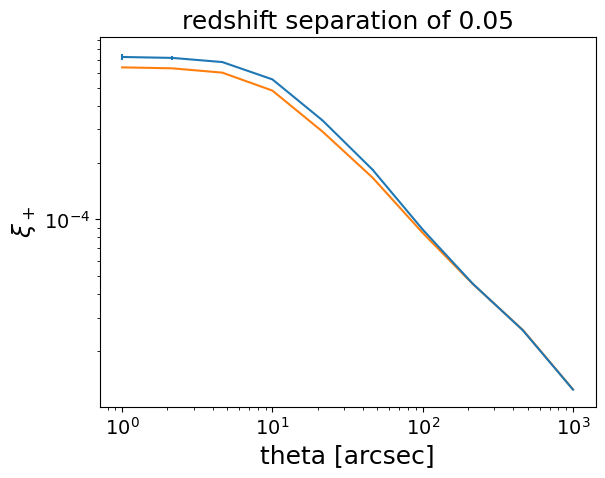

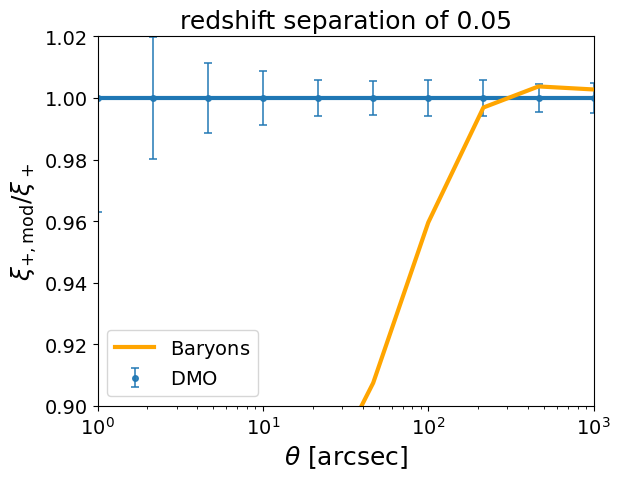

In [13]:
# plot ratio with error bars with halfsky 
xi_err =  np.sqrt(diag_IA_xip_delz)
xi_err_halfsky = 1/np.sqrt(209) * xi_err

plt.errorbar(theta_deg*3600, xi_plus, xi_err_halfsky)
plt.plot(theta_deg*3600, xi_plus_mod, label=f'mod, beta={cfg.beta}')

plt.loglog()
plt.xlabel('theta [arcsec]')
plt.ylabel(r'$\xi_+$')
plt.title(f'redshift separation of {redshift_separation}')
plt.show()

plt.errorbar(
    theta_deg * 3600,
    xi_plus / xi_plus,
    yerr= xi_err_halfsky / xi_plus,
    fmt='o',                 # marker style
    markersize=4,
    color='tab:blue',
    ecolor='tab:blue',       # error bar color
    elinewidth=1.2,          # thickness of error bars
    capsize=3,               # little caps at the end
    capthick=1.2,
    linestyle='none',        # no connecting line
    alpha=0.9,
    label=r'$\mathrm{DMO}$'
)
plt.plot(theta_deg*3600, xi_plus/xi_plus, xi_err_halfsky/xi_plus, linewidth=3)
plt.plot(theta_deg*3600, xi_plus_mod/xi_plus, label=r'$\mathrm{Baryons}$', color='orange', linewidth=3)
plt.legend()
plt.xlim(1, 1e3)
plt.ylim(0.9, 1.02)
plt.xscale('log')
plt.xlabel(r'$\theta$ [arcsec]')
plt.ylabel(r'$\xi_{+, \mathrm{mod}}/\xi_+$')
plt.title(f'redshift separation of {redshift_separation}')
# plt.savefig("plots_mock_measurements/mock_measurements.pdf")
plt.show()
